In [1]:
# ============================================
# EMPLOYEE ATTRITION PREDICTION
# STEP 1: IMPORT LIBRARIES & LOAD DATA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "../data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

# Display basic information
print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully!
Rows: 1470
Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# ============================================
# STEP 2: DATASET OVERVIEW
# ============================================

# Display all column names
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\n" + "=" * 60)

# Display data types and non-null counts
print("DATASET INFORMATION:")
df.info()

print("\n" + "=" * 60)

# Check missing values
print("MISSING VALUES:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n" + "=" * 60)

# Check duplicate rows
print("DUPLICATE ROWS:", df.duplicated().sum())

print("\n" + "=" * 60)

# Statistical summary for numerical columns
print("NUMERICAL SUMMARY:")
display(df.describe())

COLUMN NAMES:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel   

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


ATTRITION COUNTS:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

ATTRITION PERCENTAGE:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64



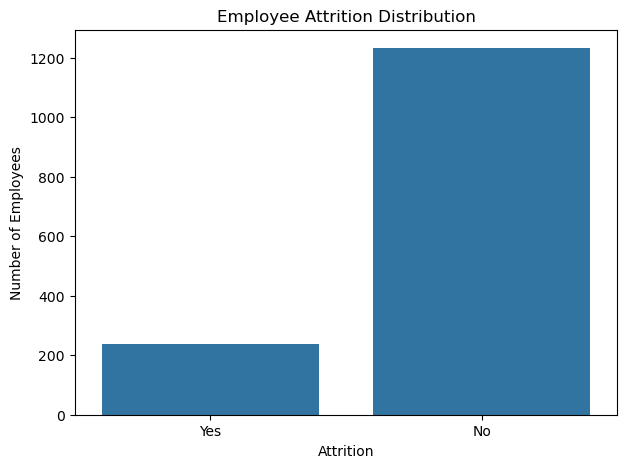

In [3]:
# ============================================
# STEP 3: ATTRITION DISTRIBUTION
# ============================================

# Count employees in each attrition category
attrition_counts = df["Attrition"].value_counts()

print("ATTRITION COUNTS:")
print(attrition_counts)

print("\n" + "=" * 60)

# Calculate percentages
attrition_percentage = df["Attrition"].value_counts(normalize=True) * 100

print("ATTRITION PERCENTAGE:")
print(attrition_percentage.round(2))

print("\n" + "=" * 60)

# Visualize attrition distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [4]:
# ============================================
# STEP 4: DATA QUALITY CHECK
# ============================================

# 1. Missing values
print("MISSING VALUES")
print("=" * 50)

missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing[missing > 0])

print("\n" + "=" * 60)

# 2. Duplicate rows
print("DUPLICATE ROWS")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n" + "=" * 60)

# 3. Data types
print("DATA TYPES")
print("=" * 50)

print(df.dtypes)

print("\n" + "=" * 60)

# 4. Number of unique values in each column
print("UNIQUE VALUES")
print("=" * 50)

unique_values = df.nunique().sort_values()

print(unique_values)

print("\n" + "=" * 60)

# 5. Constant columns
print("CONSTANT COLUMNS")
print("=" * 50)

constant_columns = [
    column for column in df.columns
    if df[column].nunique() <= 1
]

if len(constant_columns) == 0:
    print("No constant columns found.")
else:
    print(constant_columns)

MISSING VALUES
No missing values found.

DUPLICATE ROWS
Number of duplicate rows: 0

DATA TYPES
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     

In [5]:
# ============================================
# STEP 5: DATA CLEANING
# ============================================

# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

# Columns that do not provide useful predictive information
columns_to_drop = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]

# Remove unnecessary columns
df_clean.drop(columns=columns_to_drop, inplace=True)

# Display the removed columns
print("REMOVED COLUMNS:")
print(columns_to_drop)

print("\n" + "=" * 60)

# Display new dataset dimensions
print("DATASET AFTER CLEANING:")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

print("\n" + "=" * 60)

# Verify missing values
print("MISSING VALUES AFTER CLEANING:")
print(df_clean.isnull().sum().sum())

print("\n" + "=" * 60)

# Verify duplicates
print("DUPLICATE ROWS AFTER CLEANING:")
print(df_clean.duplicated().sum())

print("\n" + "=" * 60)

# Display remaining columns
print("REMAINING COLUMNS:")
print(df_clean.columns.tolist())

REMOVED COLUMNS:
['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

DATASET AFTER CLEANING:
Rows: 1470
Columns: 31

MISSING VALUES AFTER CLEANING:
0

DUPLICATE ROWS AFTER CLEANING:
0

REMAINING COLUMNS:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


AGE STATISTICS
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64



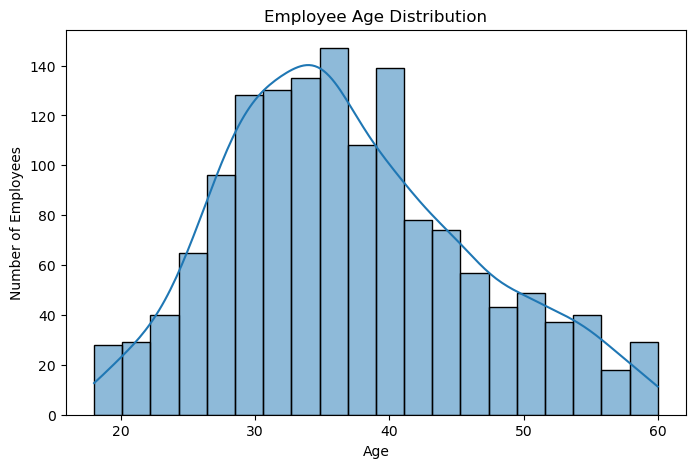


GENDER VS ATTRITION
Attrition     No    Yes
Gender                 
Female     85.20  14.80
Male       82.99  17.01


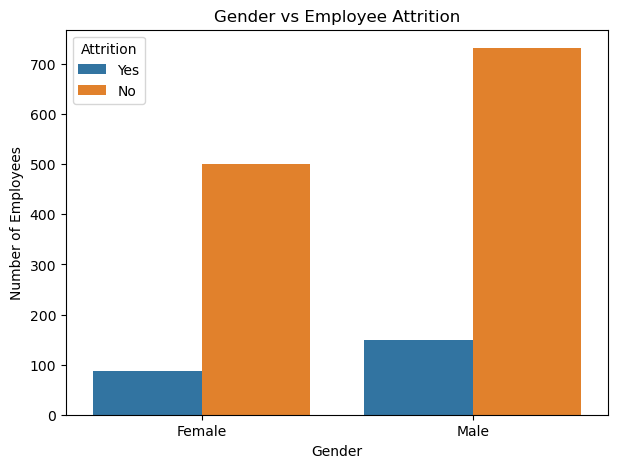


MARITAL STATUS VS ATTRITION
Attrition         No    Yes
MaritalStatus              
Divorced       89.91  10.09
Married        87.52  12.48
Single         74.47  25.53


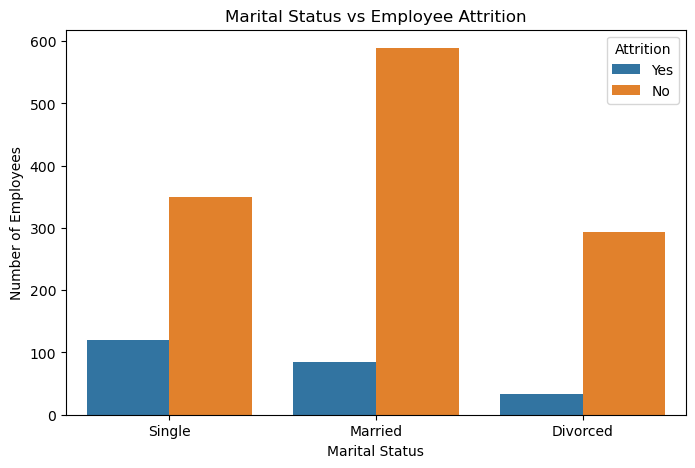


BUSINESS TRAVEL VS ATTRITION
Attrition             No    Yes
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


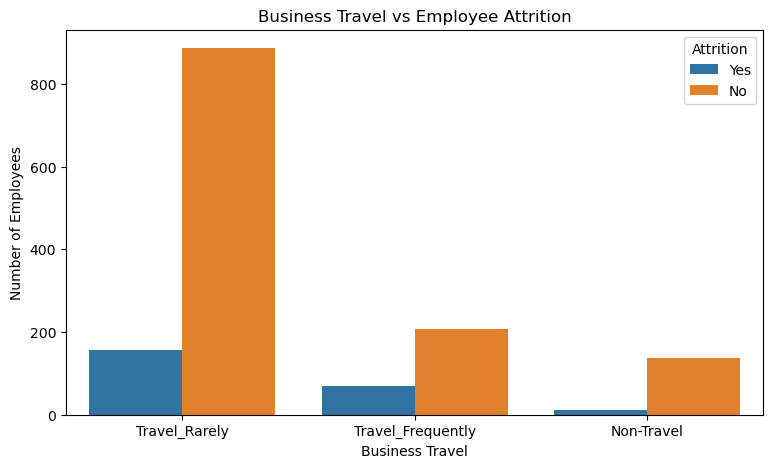


DISTANCE FROM HOME VS ATTRITION
Attrition
No      8.92
Yes    10.63
Name: DistanceFromHome, dtype: float64


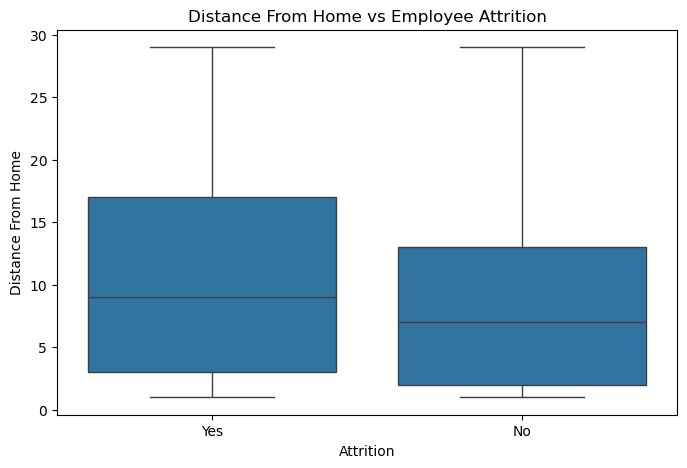

In [6]:
# ============================================
# STEP 6: EMPLOYEE DEMOGRAPHICS ANALYSIS
# ============================================

# ---------- AGE DISTRIBUTION ----------

print("AGE STATISTICS")
print("=" * 50)
print(df_clean["Age"].describe())

print("\n" + "=" * 60)

# Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()


# ---------- GENDER VS ATTRITION ----------

print("\nGENDER VS ATTRITION")
print("=" * 50)

gender_attrition = pd.crosstab(
    df_clean["Gender"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(gender_attrition.round(2))

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Gender",
    hue="Attrition"
)

plt.title("Gender vs Employee Attrition")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()


# ---------- MARITAL STATUS VS ATTRITION ----------

print("\nMARITAL STATUS VS ATTRITION")
print("=" * 50)

marital_attrition = pd.crosstab(
    df_clean["MaritalStatus"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(marital_attrition.round(2))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="MaritalStatus",
    hue="Attrition"
)

plt.title("Marital Status vs Employee Attrition")
plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.show()


# ---------- BUSINESS TRAVEL VS ATTRITION ----------

print("\nBUSINESS TRAVEL VS ATTRITION")
print("=" * 50)

travel_attrition = pd.crosstab(
    df_clean["BusinessTravel"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(travel_attrition.round(2))

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="BusinessTravel",
    hue="Attrition"
)

plt.title("Business Travel vs Employee Attrition")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")

plt.show()


# ---------- DISTANCE FROM HOME VS ATTRITION ----------

print("\nDISTANCE FROM HOME VS ATTRITION")
print("=" * 50)

distance_attrition = df_clean.groupby("Attrition")[
    "DistanceFromHome"
].mean()

print(distance_attrition.round(2))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.show()

EDUCATION VS ATTRITION
Attrition         No    Yes
Education                  
Below College  81.76  18.24
College        84.40  15.60
Bachelor       82.69  17.31
Master         85.43  14.57
Doctor         89.58  10.42



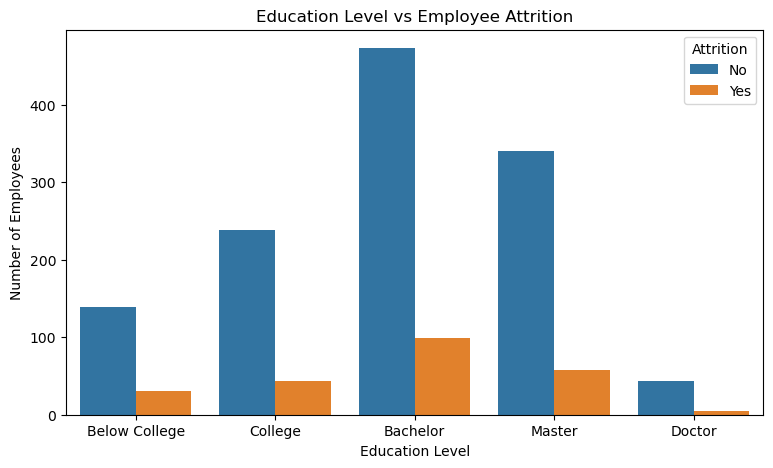

In [7]:
# ============================================
# STEP 7: EDUCATION VS ATTRITION
# ============================================

print("EDUCATION VS ATTRITION")
print("=" * 50)

# Education levels:
# 1 = Below College
# 2 = College
# 3 = Bachelor
# 4 = Master
# 5 = Doctor

education_labels = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

education_attrition = pd.crosstab(
    df_clean["Education"],
    df_clean["Attrition"],
    normalize="index"
) * 100

education_attrition.index = education_attrition.index.map(education_labels)

print(education_attrition.round(2))

print("\n" + "=" * 60)

# Visualization
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="Education",
    hue="Attrition"
)

plt.title("Education Level vs Employee Attrition")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")

plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        "Below College",
        "College",
        "Bachelor",
        "Master",
        "Doctor"
    ]
)

plt.show()

DEPARTMENT VS ATTRITION
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63



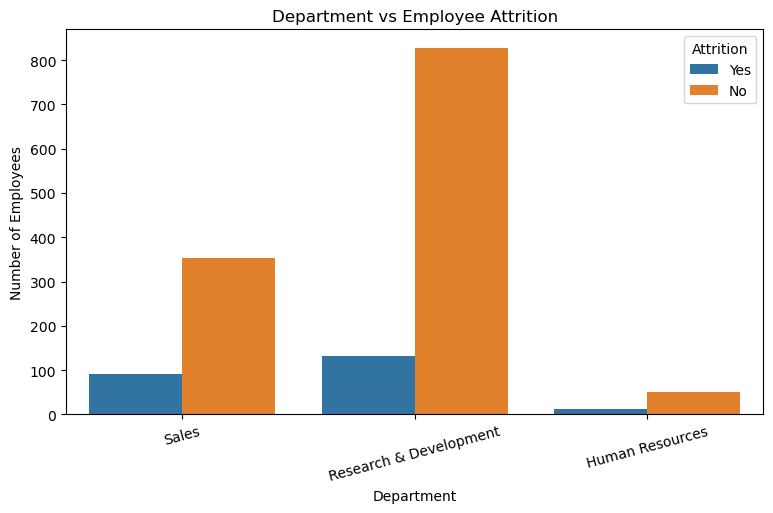


JOB ROLE VS ATTRITION
Attrition                     No    Yes
JobRole                                
Healthcare Representative  93.13   6.87
Human Resources            76.92  23.08
Laboratory Technician      76.06  23.94
Manager                    95.10   4.90
Manufacturing Director     93.10   6.90
Research Director          97.50   2.50
Research Scientist         83.90  16.10
Sales Executive            82.52  17.48
Sales Representative       60.24  39.76



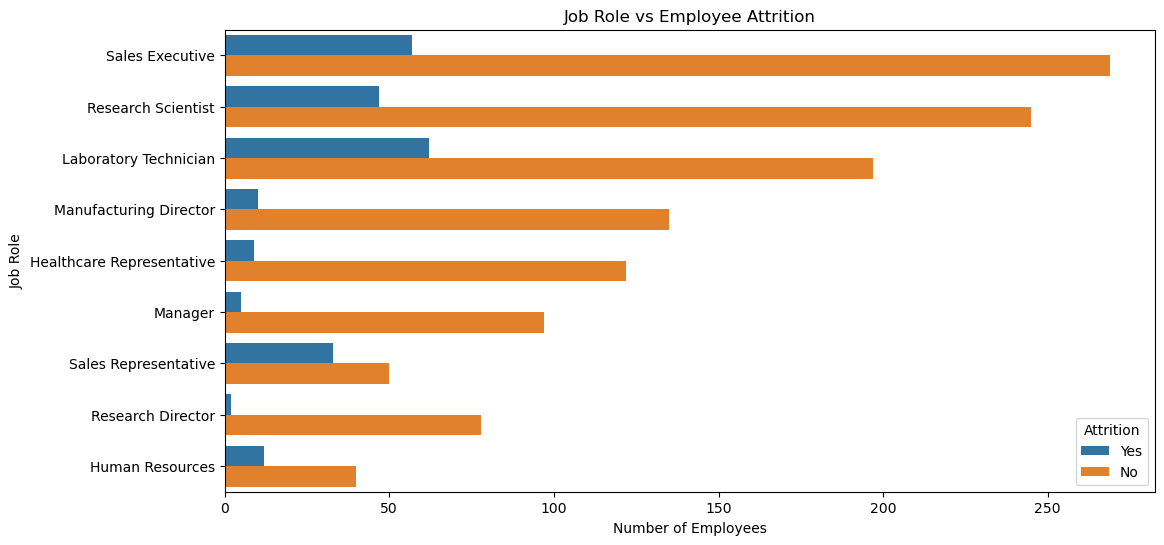


ATTRITION RATE BY JOB ROLE
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [8]:
# ============================================
# STEP 8: DEPARTMENT & JOB ROLE ANALYSIS
# ============================================

# ---------- DEPARTMENT VS ATTRITION ----------

print("DEPARTMENT VS ATTRITION")
print("=" * 50)

department_attrition = pd.crosstab(
    df_clean["Department"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(department_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="Department",
    hue="Attrition"
)

plt.title("Department vs Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.show()


# ---------- JOB ROLE VS ATTRITION ----------

print("\nJOB ROLE VS ATTRITION")
print("=" * 50)

job_role_attrition = pd.crosstab(
    df_clean["JobRole"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(job_role_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_clean,
    y="JobRole",
    hue="Attrition"
)

plt.title("Job Role vs Employee Attrition")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()


# ---------- ATTRITION RATE BY JOB ROLE ----------

print("\nATTRITION RATE BY JOB ROLE")
print("=" * 50)

job_role_rate = (
    df_clean.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_role_rate.round(2))

MONTHLY INCOME VS ATTRITION
              mean  median   min    max
Attrition                              
No         6832.74  5204.0  1051  19999
Yes        4787.09  3202.0  1009  19859



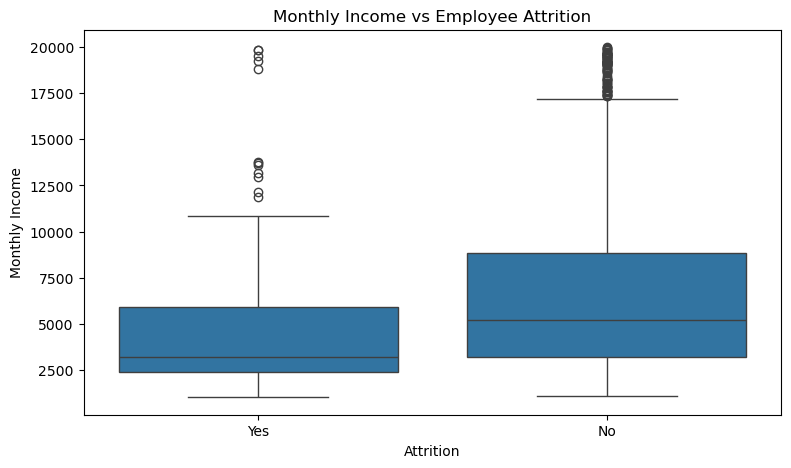


PERCENT SALARY HIKE VS ATTRITION
            mean  median
Attrition               
No         15.23    14.0
Yes        15.10    14.0



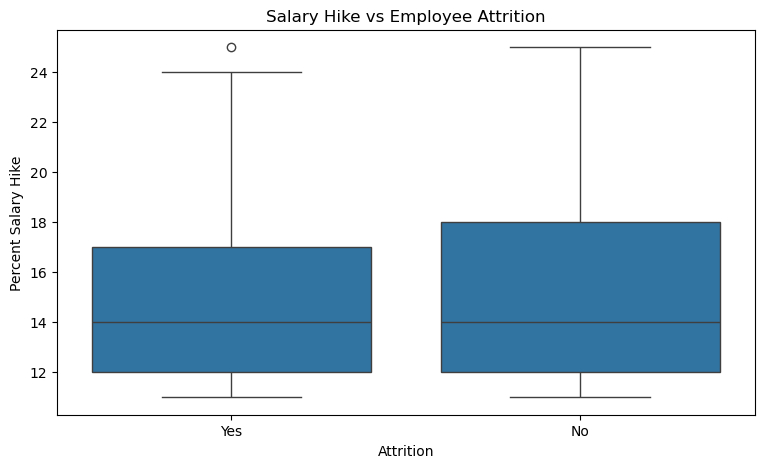


STOCK OPTION LEVEL VS ATTRITION
Attrition            No    Yes
StockOptionLevel              
0                 75.59  24.41
1                 90.60   9.40
2                 92.41   7.59
3                 82.35  17.65



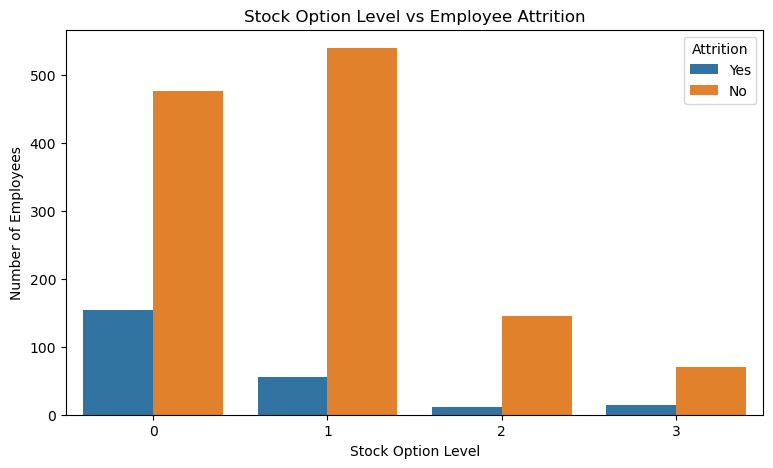


HOURLY RATE VS ATTRITION
Attrition
No     65.95
Yes    65.57
Name: HourlyRate, dtype: float64

DAILY RATE VS ATTRITION
Attrition
No     812.50
Yes    750.36
Name: DailyRate, dtype: float64


In [9]:
# ============================================
# STEP 9: SALARY & COMPENSATION ANALYSIS
# ============================================

# ---------- MONTHLY INCOME ----------

print("MONTHLY INCOME VS ATTRITION")
print("=" * 50)

income_stats = df_clean.groupby("Attrition")["MonthlyIncome"].agg(
    ["mean", "median", "min", "max"]
)

print(income_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()


# ---------- PERCENT SALARY HIKE ----------

print("\nPERCENT SALARY HIKE VS ATTRITION")
print("=" * 50)

salary_hike_stats = df_clean.groupby("Attrition")[
    "PercentSalaryHike"
].agg(["mean", "median"])

print(salary_hike_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="PercentSalaryHike"
)

plt.title("Salary Hike vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Percent Salary Hike")

plt.show()


# ---------- STOCK OPTION LEVEL ----------

print("\nSTOCK OPTION LEVEL VS ATTRITION")
print("=" * 50)

stock_attrition = pd.crosstab(
    df_clean["StockOptionLevel"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(stock_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="StockOptionLevel",
    hue="Attrition"
)

plt.title("Stock Option Level vs Employee Attrition")
plt.xlabel("Stock Option Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- HOURLY RATE ----------

print("\nHOURLY RATE VS ATTRITION")
print("=" * 50)

hourly_stats = df_clean.groupby("Attrition")[
    "HourlyRate"
].mean()

print(hourly_stats.round(2))


# ---------- DAILY RATE ----------

print("\nDAILY RATE VS ATTRITION")
print("=" * 50)

daily_stats = df_clean.groupby("Attrition")[
    "DailyRate"
].mean()

print(daily_stats.round(2))

JOB SATISFACTION VS ATTRITION
Attrition           No    Yes
JobSatisfaction              
1                77.16  22.84
2                83.57  16.43
3                83.48  16.52
4                88.67  11.33



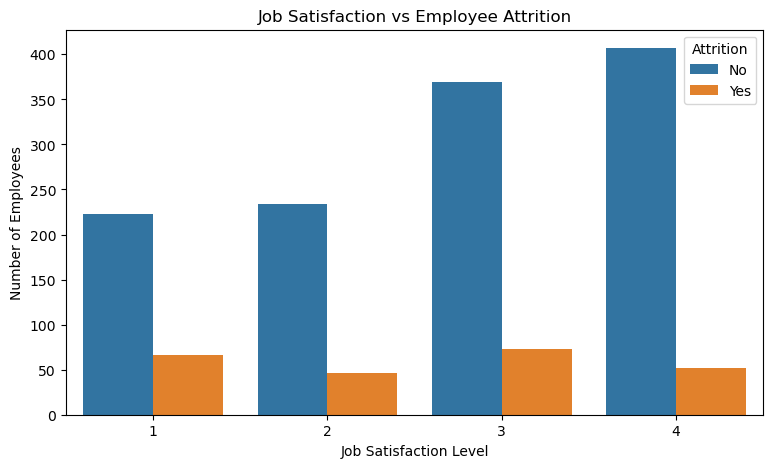


ENVIRONMENT SATISFACTION VS ATTRITION
Attrition                   No    Yes
EnvironmentSatisfaction              
1                        74.65  25.35
2                        85.02  14.98
3                        86.31  13.69
4                        86.55  13.45



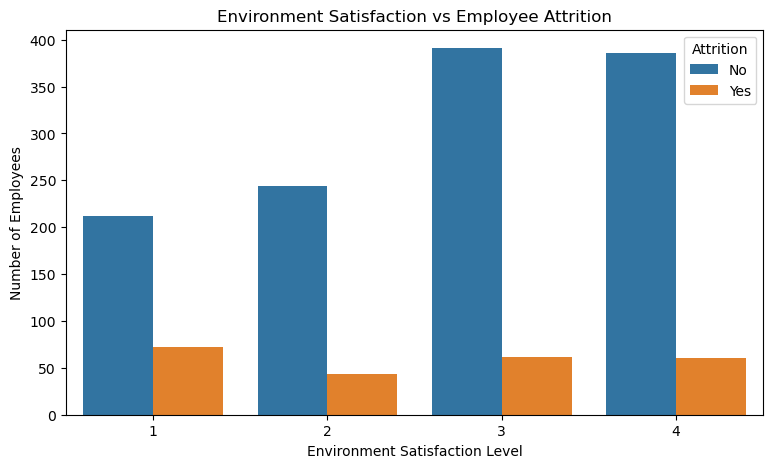


WORK-LIFE BALANCE VS ATTRITION
Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65



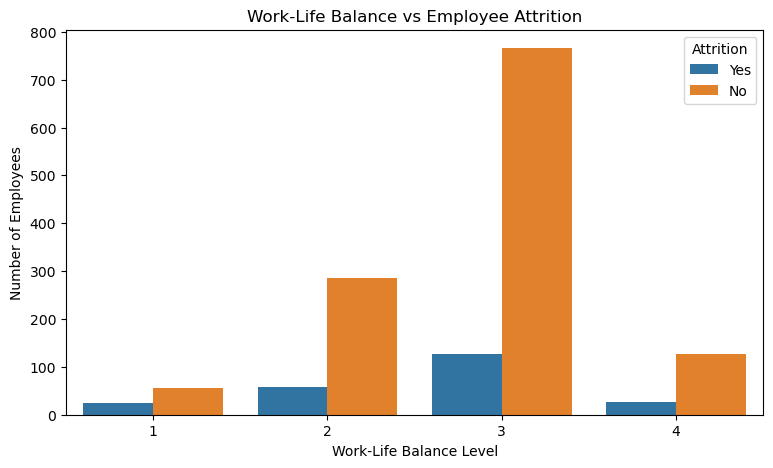


JOB INVOLVEMENT VS ATTRITION
Attrition          No    Yes
JobInvolvement              
1               66.27  33.73
2               81.07  18.93
3               85.60  14.40
4               90.97   9.03



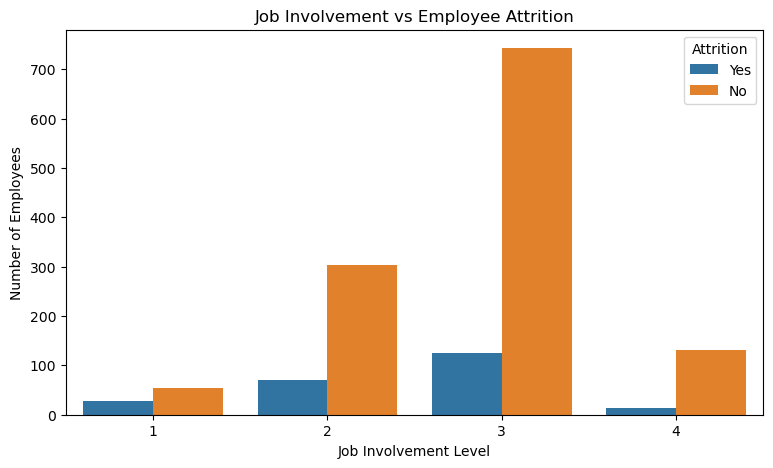


RELATIONSHIP SATISFACTION VS ATTRITION
Attrition                    No    Yes
RelationshipSatisfaction              
1                         79.35  20.65
2                         85.15  14.85
3                         84.53  15.47
4                         85.19  14.81

OVERTIME VS ATTRITION
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53



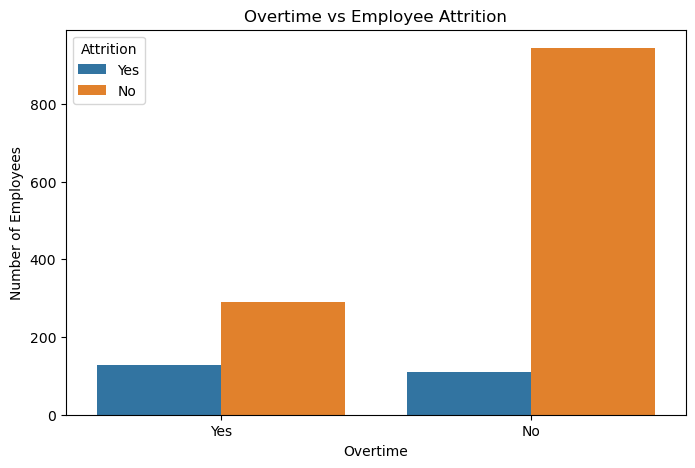

In [10]:
# ============================================
# STEP 10: EMPLOYEE SATISFACTION & WORK-LIFE
# ============================================

# Rating meanings:
# 1 = Low
# 2 = Medium
# 3 = High
# 4 = Very High


# ---------- JOB SATISFACTION ----------

print("JOB SATISFACTION VS ATTRITION")
print("=" * 50)

job_satisfaction = pd.crosstab(
    df_clean["JobSatisfaction"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(job_satisfaction.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- ENVIRONMENT SATISFACTION ----------

print("\nENVIRONMENT SATISFACTION VS ATTRITION")
print("=" * 50)

environment_satisfaction = pd.crosstab(
    df_clean["EnvironmentSatisfaction"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(environment_satisfaction.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="EnvironmentSatisfaction",
    hue="Attrition"
)

plt.title("Environment Satisfaction vs Employee Attrition")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- WORK-LIFE BALANCE ----------

print("\nWORK-LIFE BALANCE VS ATTRITION")
print("=" * 50)

worklife_attrition = pd.crosstab(
    df_clean["WorkLifeBalance"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(worklife_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Employee Attrition")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- JOB INVOLVEMENT ----------

print("\nJOB INVOLVEMENT VS ATTRITION")
print("=" * 50)

job_involvement = pd.crosstab(
    df_clean["JobInvolvement"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(job_involvement.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="JobInvolvement",
    hue="Attrition"
)

plt.title("Job Involvement vs Employee Attrition")
plt.xlabel("Job Involvement Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- RELATIONSHIP SATISFACTION ----------

print("\nRELATIONSHIP SATISFACTION VS ATTRITION")
print("=" * 50)

relationship_satisfaction = pd.crosstab(
    df_clean["RelationshipSatisfaction"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(relationship_satisfaction.round(2))


# ---------- OVERTIME ----------

print("\nOVERTIME VS ATTRITION")
print("=" * 50)

overtime_attrition = pd.crosstab(
    df_clean["OverTime"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(overtime_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="OverTime",
    hue="Attrition"
)

plt.title("Overtime vs Employee Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.show()

TOTAL WORKING YEARS VS ATTRITION
            mean  median
Attrition               
No         11.86    10.0
Yes         8.24     7.0



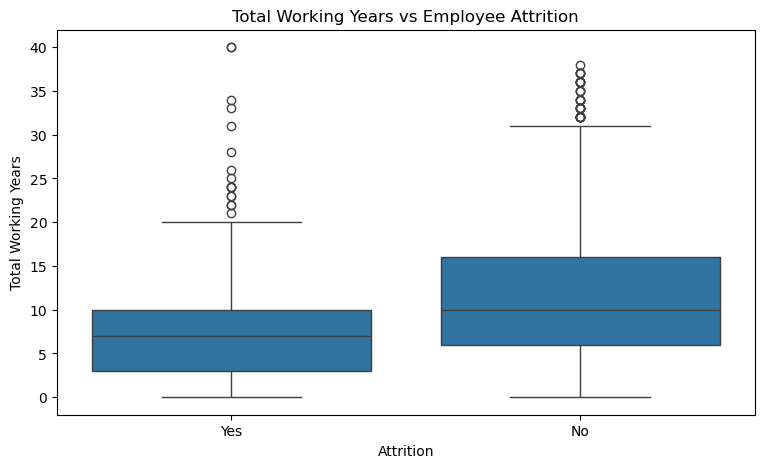


YEARS AT COMPANY VS ATTRITION
           mean  median
Attrition              
No         7.37     6.0
Yes        5.13     3.0



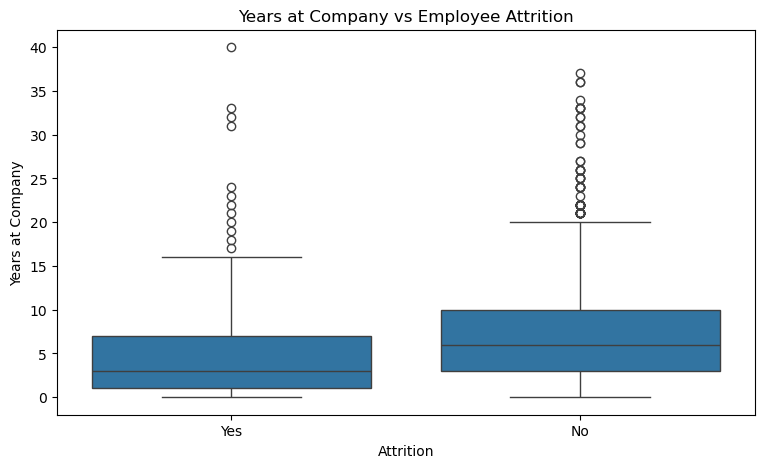


YEARS IN CURRENT ROLE VS ATTRITION
           mean  median
Attrition              
No         4.48     3.0
Yes        2.90     2.0



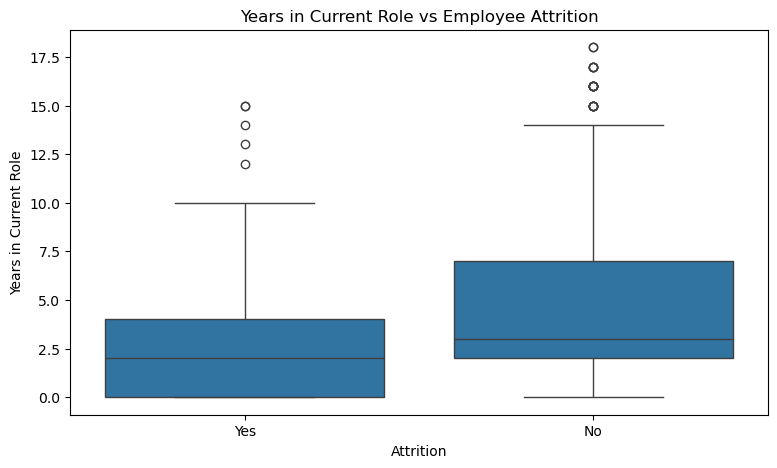


YEARS SINCE LAST PROMOTION VS ATTRITION
           mean  median
Attrition              
No         2.23     1.0
Yes        1.95     1.0



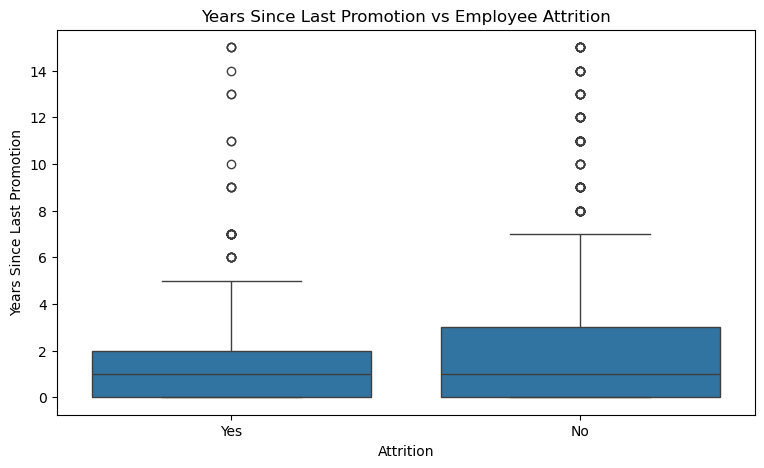


YEARS WITH CURRENT MANAGER VS ATTRITION
           mean  median
Attrition              
No         4.37     3.0
Yes        2.85     2.0



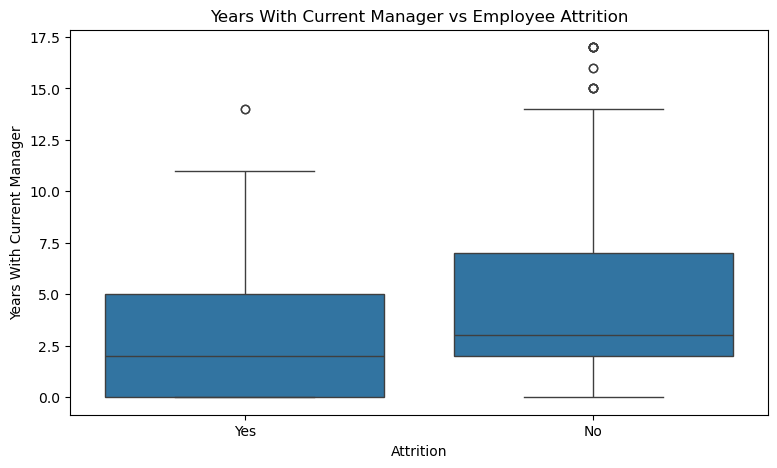


JOB LEVEL VS ATTRITION
Attrition     No    Yes
JobLevel               
1          73.66  26.34
2          90.26   9.74
3          85.32  14.68
4          95.28   4.72
5          92.75   7.25



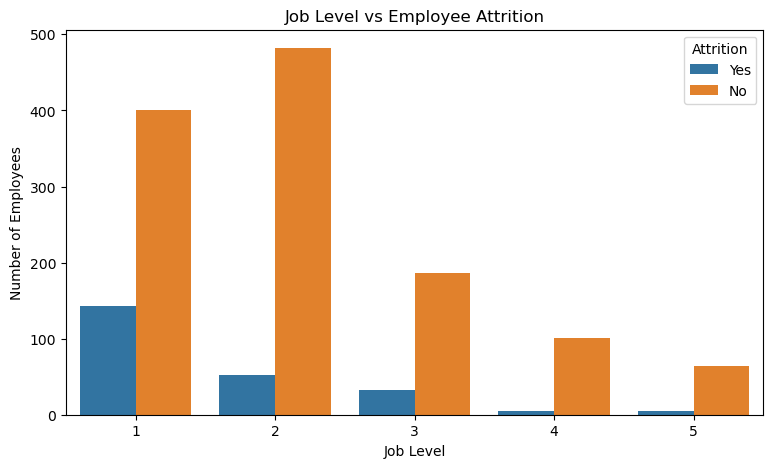


NUMBER OF COMPANIES WORKED VS ATTRITION
           mean  median
Attrition              
No         2.65     2.0
Yes        2.94     1.0


In [11]:
# ============================================
# STEP 11: EXPERIENCE, TENURE & CAREER GROWTH
# ============================================

# ---------- TOTAL WORKING YEARS ----------

print("TOTAL WORKING YEARS VS ATTRITION")
print("=" * 50)

working_years_stats = df_clean.groupby("Attrition")[
    "TotalWorkingYears"
].agg(["mean", "median"])

print(working_years_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="TotalWorkingYears"
)

plt.title("Total Working Years vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Total Working Years")

plt.show()


# ---------- YEARS AT COMPANY ----------

print("\nYEARS AT COMPANY VS ATTRITION")
print("=" * 50)

company_tenure_stats = df_clean.groupby("Attrition")[
    "YearsAtCompany"
].agg(["mean", "median"])

print(company_tenure_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()


# ---------- YEARS IN CURRENT ROLE ----------

print("\nYEARS IN CURRENT ROLE VS ATTRITION")
print("=" * 50)

current_role_stats = df_clean.groupby("Attrition")[
    "YearsInCurrentRole"
].agg(["mean", "median"])

print(current_role_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="YearsInCurrentRole"
)

plt.title("Years in Current Role vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years in Current Role")

plt.show()


# ---------- YEARS SINCE LAST PROMOTION ----------

print("\nYEARS SINCE LAST PROMOTION VS ATTRITION")
print("=" * 50)

promotion_stats = df_clean.groupby("Attrition")[
    "YearsSinceLastPromotion"
].agg(["mean", "median"])

print(promotion_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="YearsSinceLastPromotion"
)

plt.title("Years Since Last Promotion vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years Since Last Promotion")

plt.show()


# ---------- YEARS WITH CURRENT MANAGER ----------

print("\nYEARS WITH CURRENT MANAGER VS ATTRITION")
print("=" * 50)

manager_stats = df_clean.groupby("Attrition")[
    "YearsWithCurrManager"
].agg(["mean", "median"])

print(manager_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="YearsWithCurrManager"
)

plt.title("Years With Current Manager vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years With Current Manager")

plt.show()


# ---------- JOB LEVEL ----------

print("\nJOB LEVEL VS ATTRITION")
print("=" * 50)

job_level_attrition = pd.crosstab(
    df_clean["JobLevel"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(job_level_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="JobLevel",
    hue="Attrition"
)

plt.title("Job Level vs Employee Attrition")
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.show()


# ---------- NUMBER OF COMPANIES WORKED ----------

print("\nNUMBER OF COMPANIES WORKED VS ATTRITION")
print("=" * 50)

companies_stats = df_clean.groupby("Attrition")[
    "NumCompaniesWorked"
].agg(["mean", "median"])

print(companies_stats.round(2))

PERFORMANCE RATING VS ATTRITION
Attrition             No    Yes
PerformanceRating              
3                  83.92  16.08
4                  83.63  16.37



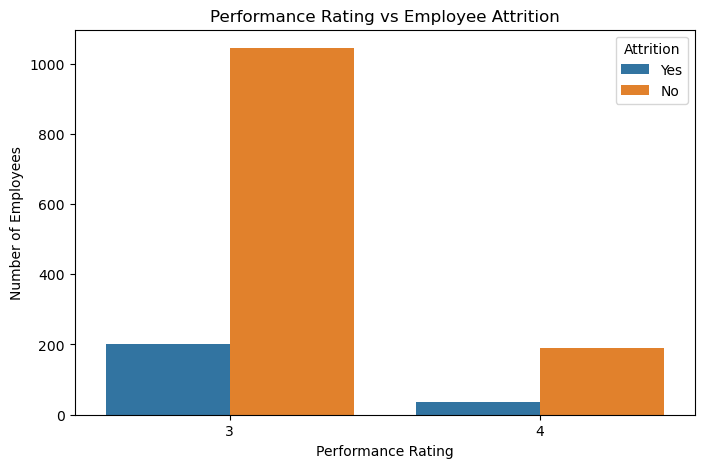


TRAINING TIMES LAST YEAR VS ATTRITION
           mean  median
Attrition              
No         2.83     3.0
Yes        2.62     2.0



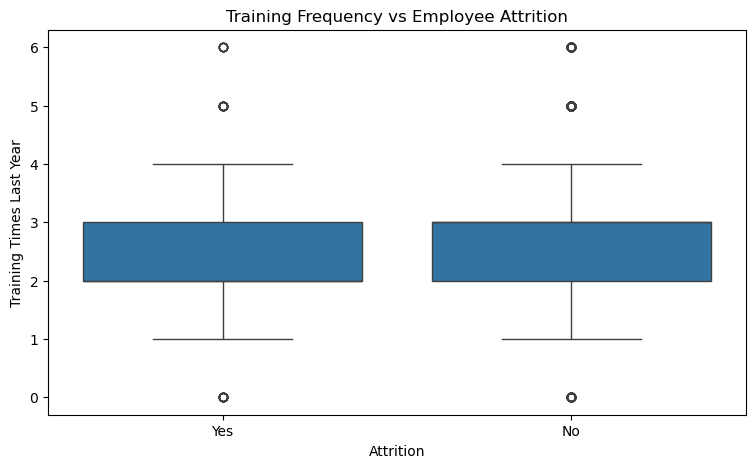


ATTRITION RATE BY JOB LEVEL
JobLevel
1    26.34
3    14.68
2     9.74
5     7.25
4     4.72
Name: Attrition, dtype: float64

ATTRITION RATE BY JOB INVOLVEMENT
JobInvolvement
1    33.73
2    18.93
3    14.40
4     9.03
Name: Attrition, dtype: float64

PROMOTION GAP VS ATTRITION
Attrition
No     2.23
Yes    1.95
Name: YearsSinceLastPromotion, dtype: float64

PERFORMANCE AND JOB SATISFACTION
JobSatisfaction        1      2      3      4
PerformanceRating                            
3                  19.37  19.05  31.03  30.55
4                  21.24  19.03  24.78  34.96


In [12]:
# ============================================
# STEP 12: PERFORMANCE & CAREER DEVELOPMENT
# ============================================

# ---------- PERFORMANCE RATING ----------

print("PERFORMANCE RATING VS ATTRITION")
print("=" * 50)

performance_attrition = pd.crosstab(
    df_clean["PerformanceRating"],
    df_clean["Attrition"],
    normalize="index"
) * 100

print(performance_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="PerformanceRating",
    hue="Attrition"
)

plt.title("Performance Rating vs Employee Attrition")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")

plt.show()


# ---------- TRAINING TIMES LAST YEAR ----------

print("\nTRAINING TIMES LAST YEAR VS ATTRITION")
print("=" * 50)

training_stats = df_clean.groupby("Attrition")[
    "TrainingTimesLastYear"
].agg(["mean", "median"])

print(training_stats.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="TrainingTimesLastYear"
)

plt.title("Training Frequency vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Training Times Last Year")

plt.show()


# ---------- JOB LEVEL ATTRITION RATE ----------

print("\nATTRITION RATE BY JOB LEVEL")
print("=" * 50)

job_level_rate = (
    df_clean.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_level_rate.round(2))

print("\n" + "=" * 60)


# ---------- JOB INVOLVEMENT ATTRITION RATE ----------

print("ATTRITION RATE BY JOB INVOLVEMENT")
print("=" * 50)

job_involvement_rate = (
    df_clean.groupby("JobInvolvement")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_involvement_rate.round(2))

print("\n" + "=" * 60)


# ---------- YEARS SINCE LAST PROMOTION ----------

print("PROMOTION GAP VS ATTRITION")
print("=" * 50)

promotion_gap = df_clean.groupby("Attrition")[
    "YearsSinceLastPromotion"
].mean()

print(promotion_gap.round(2))

print("\n" + "=" * 60)


# ---------- PERFORMANCE × JOB SATISFACTION ----------

print("PERFORMANCE AND JOB SATISFACTION")
print("=" * 50)

performance_satisfaction = pd.crosstab(
    df_clean["PerformanceRating"],
    df_clean["JobSatisfaction"],
    normalize="index"
) * 100

print(performance_satisfaction.round(2))

CORRELATION WITH ATTRITION
TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
Name: Attrition_Flag, dtype: float64

TOP POSITIVE CORRELATIONS
DistanceFromHome            0.078
NumCompaniesWorked          0.043
MonthlyRate                 0.015
PerformanceRating        

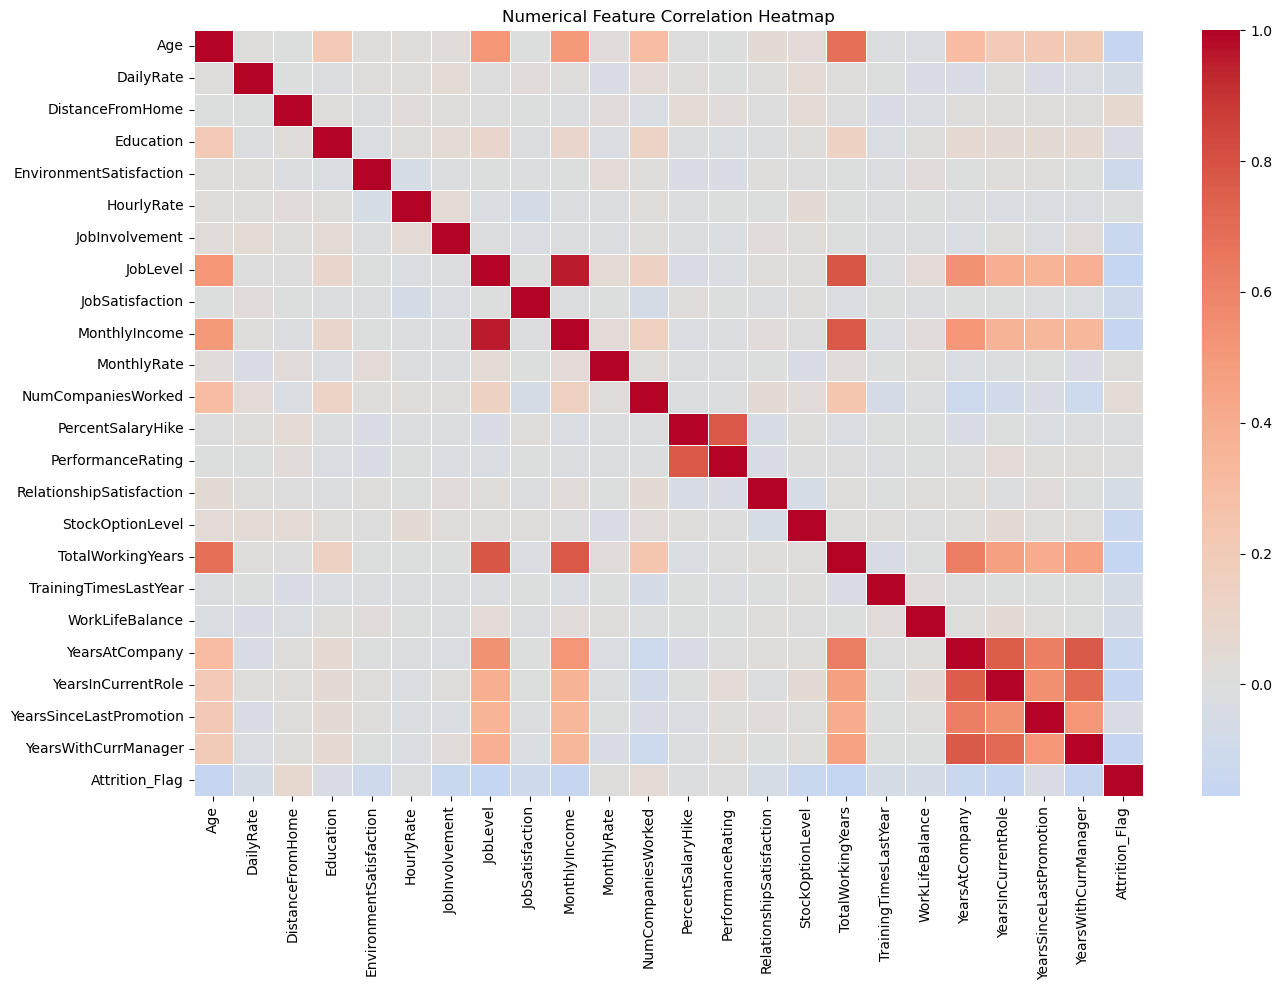


NUMERICAL FEATURES MOST ASSOCIATED WITH ATTRITION
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition_Flag, dtype: float64


In [13]:
# ============================================
# STEP 13: CORRELATION & NUMERICAL ANALYSIS
# ============================================

# Create a copy for correlation analysis
correlation_df = df_clean.copy()

# Convert Attrition into a numerical variable
# Yes = 1, No = 0
correlation_df["Attrition_Flag"] = (
    correlation_df["Attrition"].map({"Yes": 1, "No": 0})
)

# Select numerical columns
numeric_columns = correlation_df.select_dtypes(
    include=["int64", "float64"]
).columns

# Calculate correlations with attrition
attrition_correlations = (
    correlation_df[numeric_columns]
    .corr()["Attrition_Flag"]
    .drop("Attrition_Flag")
    .sort_values()
)

print("CORRELATION WITH ATTRITION")
print("=" * 60)
print(attrition_correlations.round(3))

print("\n" + "=" * 60)

# Top positive and negative correlations
print("TOP POSITIVE CORRELATIONS")
print("=" * 60)
print(attrition_correlations.tail(10).sort_values(ascending=False).round(3))

print("\n" + "=" * 60)

print("TOP NEGATIVE CORRELATIONS")
print("=" * 60)
print(attrition_correlations.head(10).round(3))


# ---------- CORRELATION HEATMAP ----------

plt.figure(figsize=(14, 10))

correlation_matrix = correlation_df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()

plt.show()


# ---------- NUMERICAL FEATURES WITH STRONGEST ASSOCIATION ----------

print("\nNUMERICAL FEATURES MOST ASSOCIATED WITH ATTRITION")
print("=" * 60)

strongest_features = (
    attrition_correlations.abs()
    .sort_values(ascending=False)
    .head(10)
)

print(strongest_features)

In [14]:
# ============================================
# STEP 14: FEATURE ENGINEERING
# ============================================

# Work on a copy of the cleaned dataset
df_model = df_clean.copy()


# ---------- AGE GROUP ----------

df_model["AgeGroup"] = pd.cut(
    df_model["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)


# ---------- INCOME GROUP ----------

df_model["IncomeGroup"] = pd.qcut(
    df_model["MonthlyIncome"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)


# ---------- TENURE GROUP ----------

df_model["TenureGroup"] = pd.cut(
    df_model["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, 100],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-20 Years",
        "20+ Years"
    ]
)


# ---------- PROMOTION GAP ----------

df_model["PromotionGap"] = (
    df_model["YearsAtCompany"]
    - df_model["YearsSinceLastPromotion"]
)


# ---------- CURRENT ROLE TENURE RATIO ----------

df_model["CurrentRoleTenureRatio"] = np.where(
    df_model["YearsAtCompany"] > 0,
    df_model["YearsInCurrentRole"] / df_model["YearsAtCompany"],
    0
)


# ---------- CAREER COMPANY RATIO ----------

df_model["CompaniesWorkedRatio"] = np.where(
    df_model["TotalWorkingYears"] > 0,
    df_model["NumCompaniesWorked"] / df_model["TotalWorkingYears"],
    0
)


# ---------- EARLY CAREER FLAG ----------

df_model["EarlyCareer"] = np.where(
    df_model["TotalWorkingYears"] <= 5,
    "Yes",
    "No"
)


# ---------- LONG COMMUTE FLAG ----------

# Employees travelling more than 10 km are classified
# as having a relatively long commute.
df_model["LongCommute"] = np.where(
    df_model["DistanceFromHome"] > 10,
    "Yes",
    "No"
)


# ---------- DISPLAY NEW FEATURES ----------

new_features = [
    "AgeGroup",
    "IncomeGroup",
    "TenureGroup",
    "PromotionGap",
    "CurrentRoleTenureRatio",
    "CompaniesWorkedRatio",
    "EarlyCareer",
    "LongCommute"
]

print("NEW FEATURES CREATED")
print("=" * 60)

print(new_features)

print("\n" + "=" * 60)

print("NEW DATASET SHAPE:")
print(f"Rows: {df_model.shape[0]}")
print(f"Columns: {df_model.shape[1]}")

print("\n" + "=" * 60)

print("SAMPLE OF ENGINEERED FEATURES:")
display(df_model[new_features].head(10))

NEW FEATURES CREATED
['AgeGroup', 'IncomeGroup', 'TenureGroup', 'PromotionGap', 'CurrentRoleTenureRatio', 'CompaniesWorkedRatio', 'EarlyCareer', 'LongCommute']

NEW DATASET SHAPE:
Rows: 1470
Columns: 39

SAMPLE OF ENGINEERED FEATURES:


,AgeGroup,IncomeGroup,TenureGroup,PromotionGap,CurrentRoleTenureRatio,CompaniesWorkedRatio,EarlyCareer,LongCommute
0,36-45,High,6-10 Years,6,0.666667,1.000000,No,No
1,46-55,High,6-10 Years,9,0.700000,0.100000,No,No
2,36-45,Low,0-2 Years,0,0.000000,0.857143,No,No
3,26-35,Low,6-10 Years,5,0.875000,0.125000,No,No
4,26-35,Medium,0-2 Years,0,1.000000,1.500000,No,No
5,26-35,Medium,6-10 Years,4,1.000000,0.000000,No,No
6,56+,Low,0-2 Years,1,0.000000,0.333333,No,No
7,26-35,Low,0-2 Years,1,0.000000,1.000000,Yes,Yes
8,36-45,Very High,6-10 Years,8,0.777778,0.000000,No,Yes
9,36-45,High,6-10 Years,0,1.000000,0.352941,No,Yes


AGE GROUP VS ATTRITION
Attrition     No    Yes
AgeGroup               
18-25      64.23  35.77
26-35      80.86  19.14
36-45      90.81   9.19
46-55      88.50  11.50
56+        82.98  17.02



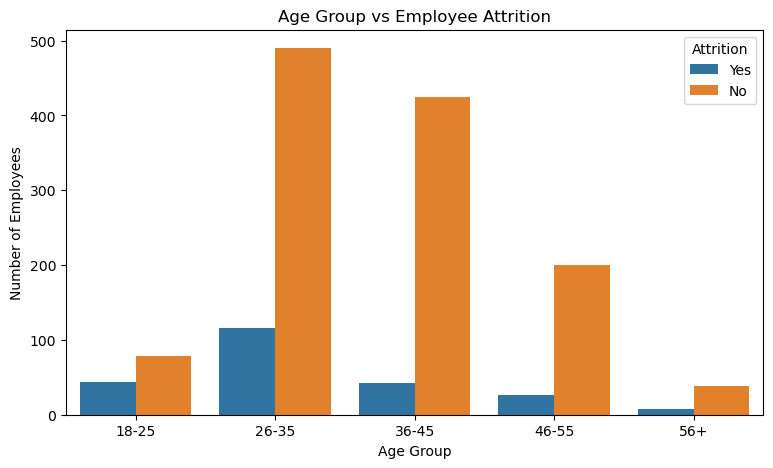


INCOME GROUP VS ATTRITION
Attrition       No    Yes
IncomeGroup              
Low          70.73  29.27
Medium       85.79  14.21
High         89.37  10.63
Very High    89.67  10.33



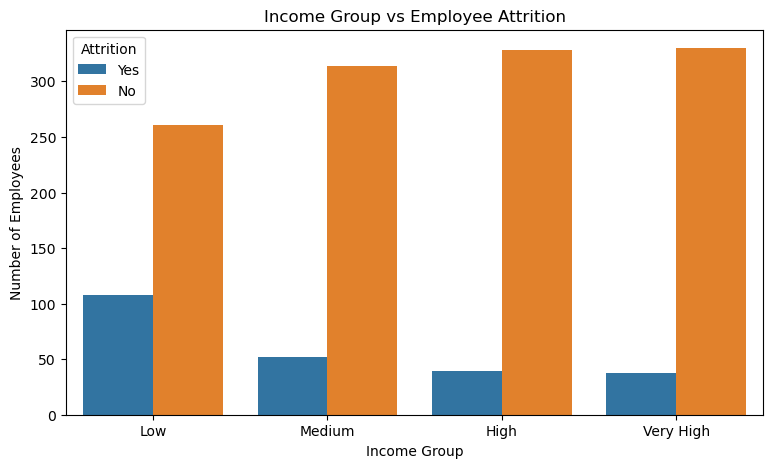


TENURE GROUP VS ATTRITION
Attrition       No    Yes
TenureGroup              
0-2 Years    70.18  29.82
3-5 Years    86.18  13.82
6-10 Years   87.72  12.28
11-20 Years  93.33   6.67
20+ Years    87.88  12.12



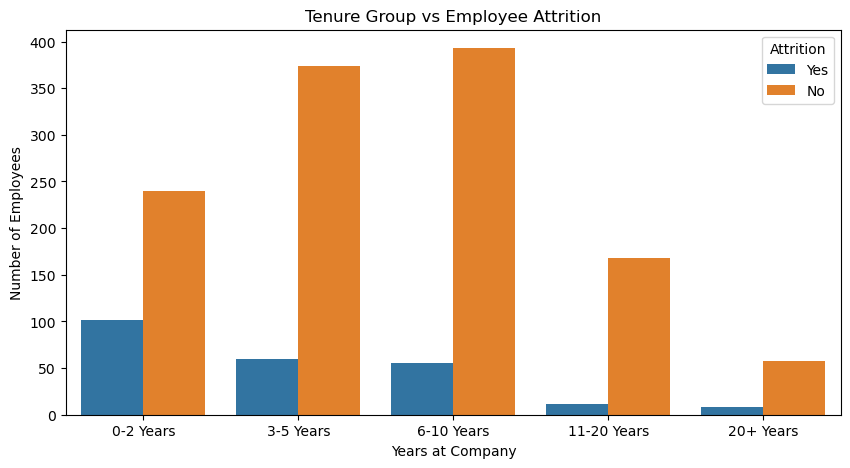


EARLY CAREER VS ATTRITION
Attrition       No    Yes
EarlyCareer              
No           87.35  12.65
Yes          71.20  28.80



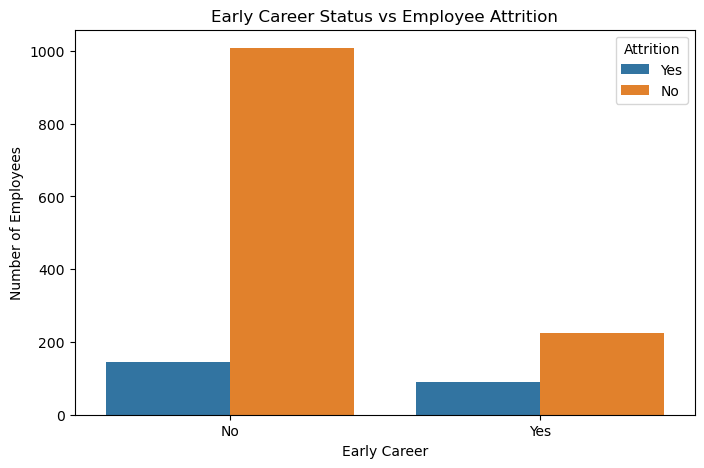


LONG COMMUTE VS ATTRITION
Attrition       No    Yes
LongCommute              
No           85.96  14.04
Yes          79.05  20.95



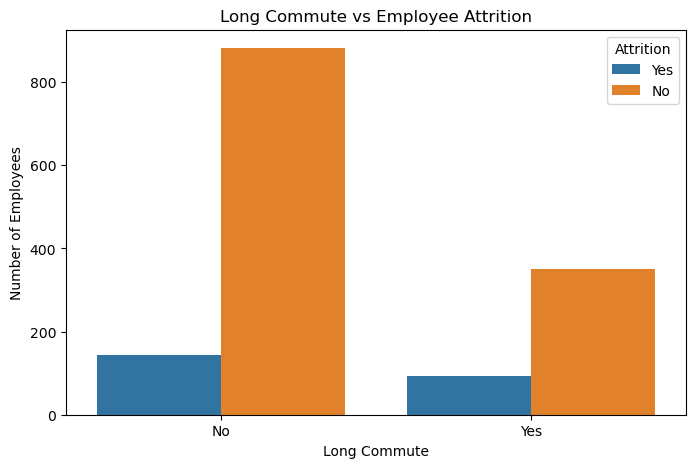

In [15]:
# ============================================
# STEP 15: ENGINEERED FEATURES VS ATTRITION
# ============================================

# ---------- AGE GROUP ----------

print("AGE GROUP VS ATTRITION")
print("=" * 60)

age_group_attrition = pd.crosstab(
    df_model["AgeGroup"],
    df_model["Attrition"],
    normalize="index"
) * 100

print(age_group_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_model,
    x="AgeGroup",
    hue="Attrition"
)

plt.title("Age Group vs Employee Attrition")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()


# ---------- INCOME GROUP ----------

print("\nINCOME GROUP VS ATTRITION")
print("=" * 60)

income_group_attrition = pd.crosstab(
    df_model["IncomeGroup"],
    df_model["Attrition"],
    normalize="index"
) * 100

print(income_group_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_model,
    x="IncomeGroup",
    hue="Attrition"
)

plt.title("Income Group vs Employee Attrition")
plt.xlabel("Income Group")
plt.ylabel("Number of Employees")

plt.show()


# ---------- TENURE GROUP ----------

print("\nTENURE GROUP VS ATTRITION")
print("=" * 60)

tenure_group_attrition = pd.crosstab(
    df_model["TenureGroup"],
    df_model["Attrition"],
    normalize="index"
) * 100

print(tenure_group_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_model,
    x="TenureGroup",
    hue="Attrition"
)

plt.title("Tenure Group vs Employee Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.show()


# ---------- EARLY CAREER ----------

print("\nEARLY CAREER VS ATTRITION")
print("=" * 60)

early_career_attrition = pd.crosstab(
    df_model["EarlyCareer"],
    df_model["Attrition"],
    normalize="index"
) * 100

print(early_career_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="EarlyCareer",
    hue="Attrition"
)

plt.title("Early Career Status vs Employee Attrition")
plt.xlabel("Early Career")
plt.ylabel("Number of Employees")

plt.show()


# ---------- LONG COMMUTE ----------

print("\nLONG COMMUTE VS ATTRITION")
print("=" * 60)

commute_attrition = pd.crosstab(
    df_model["LongCommute"],
    df_model["Attrition"],
    normalize="index"
) * 100

print(commute_attrition.round(2))

print("\n" + "=" * 60)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="LongCommute",
    hue="Attrition"
)

plt.title("Long Commute vs Employee Attrition")
plt.xlabel("Long Commute")
plt.ylabel("Number of Employees")

plt.show()

In [16]:
# ============================================
# STEP 16: MACHINE LEARNING DATA PREPARATION
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create a copy of our engineered dataset
ml_df = df_model.copy()

# ---------- TARGET VARIABLE ----------

# Convert Attrition into binary format
# Yes = 1 (employee left)
# No = 0 (employee stayed)

ml_df["Attrition"] = ml_df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# ---------- REMOVE UNNECESSARY COLUMNS ----------

# EmployeeNumber was already removed.
# We also remove Employee ID-like fields that should not
# influence the prediction.

columns_to_remove = [
    "EmployeeNumber"
]

# Remove only columns that still exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in ml_df.columns
]

ml_df.drop(columns=columns_to_remove, inplace=True)

# ---------- SEPARATE FEATURES AND TARGET ----------

X = ml_df.drop("Attrition", axis=1)
y = ml_df["Attrition"]

print("FEATURE MATRIX SHAPE:")
print(X.shape)

print("\nTARGET SHAPE:")
print(y.shape)

print("\n" + "=" * 60)

# ---------- IDENTIFY COLUMN TYPES ----------

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("NUMBER OF NUMERICAL FEATURES:", len(numeric_features))
print("NUMBER OF CATEGORICAL FEATURES:", len(categorical_features))

print("\n" + "=" * 60)

print("NUMERICAL FEATURES:")
print(numeric_features)

print("\n" + "=" * 60)

print("CATEGORICAL FEATURES:")
print(categorical_features)

print("\n" + "=" * 60)

# ---------- ONE-HOT ENCODING ----------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# ---------- TRAIN / TEST SPLIT ----------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("TRAINING SET:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTESTING SET:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\n" + "=" * 60)

# ---------- CLASS DISTRIBUTION ----------

print("TARGET DISTRIBUTION")
print("=" * 60)

print("Training set:")
print(y_train.value_counts())
print("\nTraining percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting set:")
print(y_test.value_counts())
print("\nTesting percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

FEATURE MATRIX SHAPE:
(1470, 38)

TARGET SHAPE:
(1470,)

NUMBER OF NUMERICAL FEATURES: 26
NUMBER OF CATEGORICAL FEATURES: 12

NUMERICAL FEATURES:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PromotionGap', 'CurrentRoleTenureRatio', 'CompaniesWorkedRatio']

CATEGORICAL FEATURES:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'AgeGroup', 'IncomeGroup', 'TenureGroup', 'EarlyCareer', 'LongCommute']

TRAINING SET:
X_train: (1176, 38)
y_train: (1176,)

TESTING SET:
X_test: (294, 38)
y_test: (294,)

TARGET DISTRIBUTION
Training set:
Attrition
0   

In [17]:
# ============================================
# STEP 17: MODEL TRAINING & COMPARISON
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ---------- DEFINE MODELS ----------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        max_depth=6
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# ---------- TRAIN MODELS ----------

trained_models = {}

print("TRAINING MODELS")
print("=" * 60)

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

    print(f"✓ {model_name} trained successfully")


print("\n" + "=" * 60)

print("TOTAL MODELS TRAINED:", len(trained_models))

TRAINING MODELS


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✓ Logistic Regression trained successfully
✓ Decision Tree trained successfully
✓ Random Forest trained successfully
✓ Gradient Boosting trained successfully

TOTAL MODELS TRAINED: 4


MODEL EVALUATION

Logistic Regression
--------------------------------------------------
Accuracy : 0.7449
Precision: 0.3409
Recall   : 0.6383
F1-Score : 0.4444
ROC-AUC  : 0.7940

Decision Tree
--------------------------------------------------
Accuracy : 0.7415
Precision: 0.2899
Recall   : 0.4255
F1-Score : 0.3448
ROC-AUC  : 0.5768

Random Forest
--------------------------------------------------
Accuracy : 0.8367
Precision: 0.4286
Recall   : 0.0638
F1-Score : 0.1111
ROC-AUC  : 0.7745

Gradient Boosting
--------------------------------------------------
Accuracy : 0.8503
Precision: 0.6000
Recall   : 0.1915
F1-Score : 0.2903
ROC-AUC  : 0.8040

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7449,0.3409,0.6383,0.4444,0.7940
1,Decision Tree,0.7415,0.2899,0.4255,0.3448,0.5768
3,Gradient Boosting,0.8503,0.6000,0.1915,0.2903,0.8040
2,Random Forest,0.8367,0.4286,0.0638,0.1111,0.7745



CONFUSION MATRIX — Logistic Regression
[[189  58]
 [ 17  30]]


<Figure size 600x500 with 0 Axes>

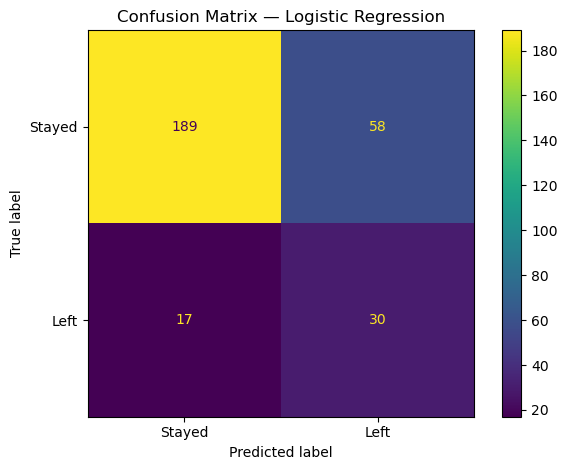


CONFUSION MATRIX — Decision Tree
[[198  49]
 [ 27  20]]


<Figure size 600x500 with 0 Axes>

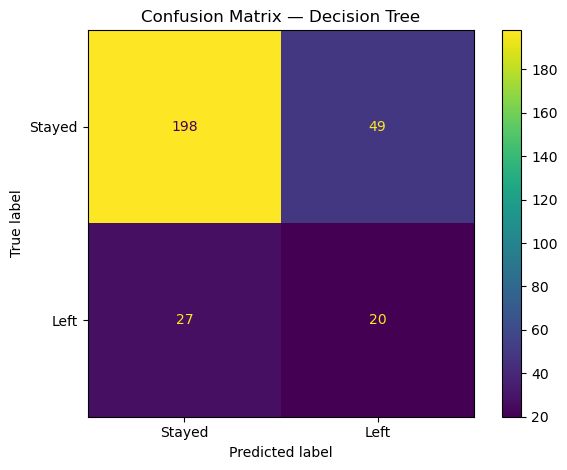


CONFUSION MATRIX — Random Forest
[[243   4]
 [ 44   3]]


<Figure size 600x500 with 0 Axes>

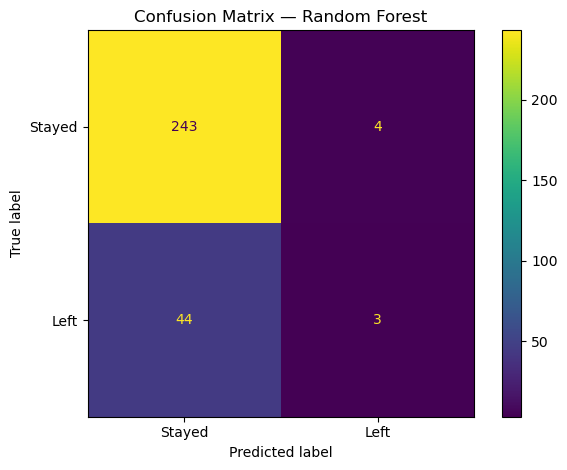


CONFUSION MATRIX — Gradient Boosting
[[241   6]
 [ 38   9]]


<Figure size 600x500 with 0 Axes>

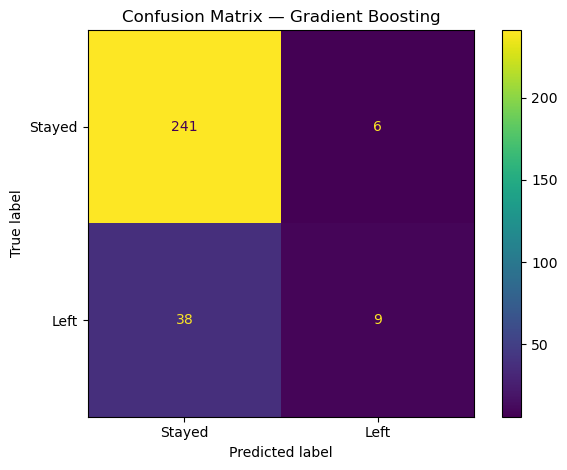

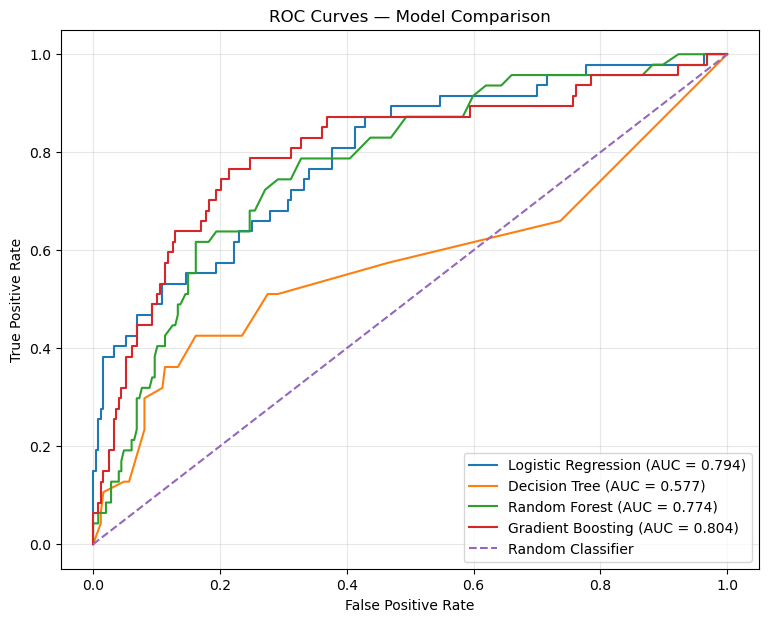

In [18]:
# ============================================
# STEP 18: MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Store evaluation results
results = []

# Store predictions
predictions = {}

print("MODEL EVALUATION")
print("=" * 70)

for model_name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of Attrition = 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    predictions[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


# ---------- RESULTS TABLE ----------

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.sort_values(
        by="F1-Score",
        ascending=False
    ).round(4)
)


# ---------- CONFUSION MATRICES ----------

for model_name, model_predictions in predictions.items():

    print(f"\nCONFUSION MATRIX — {model_name}")

    cm = confusion_matrix(
        y_test,
        model_predictions["y_pred"]
    )

    print(cm)

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Stayed", "Left"]
    ).plot()

    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()

    plt.show()


# ---------- ROC CURVES ----------

plt.figure(figsize=(9, 7))

for model_name, model_predictions in predictions.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        model_predictions["y_prob"]
    )

    auc_score = roc_auc_score(
        y_test,
        model_predictions["y_prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

BEST MODEL
Selected Model: Logistic Regression
Accuracy : 0.7449
Precision: 0.3409
Recall   : 0.6383
F1-Score : 0.4444
ROC-AUC  : 0.7940

TOP 20 FEATURES ASSOCIATED WITH ATTRITION


,Feature,Importance
0,categorical__OverTime_Yes,0.8590
1,remainder__StockOptionLevel,0.5057
2,categorical__MaritalStatus_Single,0.4622
3,categorical__IncomeGroup_Low,0.3930
4,remainder__EnvironmentSatisfaction,0.3815
5,categorical__BusinessTravel_Travel_Frequently,0.3779
6,categorical__Department_Sales,0.3695
7,categorical__AgeGroup_36-45,0.3535
8,remainder__PerformanceRating,0.3443
9,categorical__JobRole_Laboratory Technician,0.3435


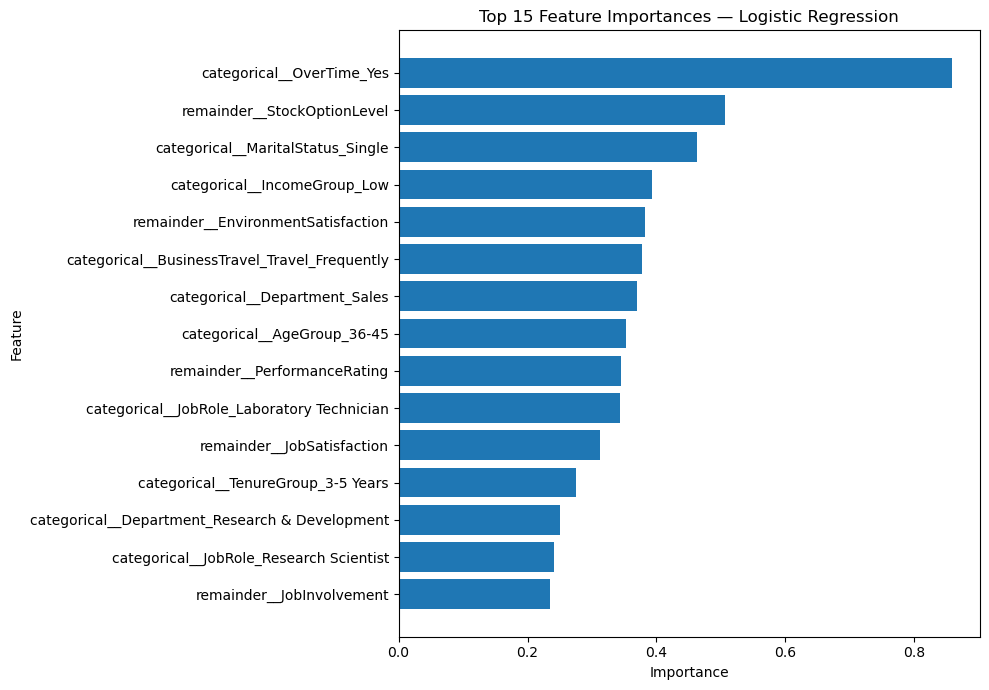

In [19]:
# ============================================
# STEP 19: BEST MODEL & FEATURE IMPORTANCE
# ============================================

# Select the best model based on F1-Score
best_model_name = (
    results_df
    .sort_values(by="F1-Score", ascending=False)
    .iloc[0]["Model"]
)

best_model = trained_models[best_model_name]

print("BEST MODEL")
print("=" * 60)
print(f"Selected Model: {best_model_name}")

best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"Accuracy : {best_result['Accuracy']:.4f}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall   : {best_result['Recall']:.4f}")
print(f"F1-Score : {best_result['F1-Score']:.4f}")
print(f"ROC-AUC  : {best_result['ROC-AUC']:.4f}")


# ---------- GET FEATURE NAMES ----------

fitted_preprocessor = best_model.named_steps["preprocessor"]
final_model = best_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()


# ---------- FEATURE IMPORTANCE ----------

if hasattr(final_model, "feature_importances_"):

    importance_values = final_model.feature_importances_

elif hasattr(final_model, "coef_"):

    importance_values = np.abs(final_model.coef_[0])

else:

    importance_values = None


if importance_values is not None:

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 60)
    print("TOP 20 FEATURES ASSOCIATED WITH ATTRITION")
    print("=" * 60)

    display(
        feature_importance_df.head(20).round(4)
    )


    # ---------- VISUALIZATION ----------

    top_features = feature_importance_df.head(15).sort_values(
        by="Importance"
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        f"Top 15 Feature Importances — {best_model_name}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

else:

    print(
        "Feature importance is not directly available "
        "for this model."
    )

In [20]:
# ============================================
# STEP 20: EMPLOYEE ATTRITION PREDICTION
# ============================================

# Select one employee from the test dataset
sample_employee = X_test.iloc[[0]]

# Get the actual attrition value
actual_value = y_test.iloc[0]

# Make prediction
predicted_value = best_model.predict(sample_employee)[0]

# Get probability of leaving
attrition_probability = best_model.predict_proba(
    sample_employee
)[0][1]

print("EMPLOYEE ATTRITION PREDICTION")
print("=" * 60)

print(f"Best Model: {best_model_name}")

print("\nPREDICTION RESULT")
print("-" * 60)

if predicted_value == 1:
    print("Predicted Attrition: YES — Employee may leave")
else:
    print("Predicted Attrition: NO — Employee may stay")

print(f"Probability of Attrition: {attrition_probability:.2%}")

print("\nACTUAL RESULT")
print("-" * 60)

if actual_value == 1:
    print("Actual Attrition: YES — Employee left")
else:
    print("Actual Attrition: NO — Employee stayed")

print("\nPREDICTION CORRECT:",
      predicted_value == actual_value)


# ---------- DISPLAY EMPLOYEE DETAILS ----------

print("\n" + "=" * 60)
print("EMPLOYEE DETAILS")
print("=" * 60)

display(
    sample_employee.T
)

EMPLOYEE ATTRITION PREDICTION
Best Model: Logistic Regression

PREDICTION RESULT
------------------------------------------------------------
Predicted Attrition: YES — Employee may leave
Probability of Attrition: 53.15%

ACTUAL RESULT
------------------------------------------------------------
Actual Attrition: NO — Employee stayed

PREDICTION CORRECT: False

EMPLOYEE DETAILS


,1061
Age,24
BusinessTravel,Non-Travel
DailyRate,830
Department,Sales
DistanceFromHome,13
Education,2
EducationField,Life Sciences
EnvironmentSatisfaction,4
Gender,Female
HourlyRate,78


In [21]:
# ============================================
# STEP 21: SAVE MODEL & PROJECT OUTPUTS
# ============================================

import os
import joblib

# ---------- CREATE OUTPUT DIRECTORIES ----------

os.makedirs("../models", exist_ok=True)
os.makedirs("../visualizations", exist_ok=True)


# ---------- SAVE BEST MODEL ----------

model_path = "../models/best_employee_attrition_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print("BEST MODEL SAVED:")
print(model_path)


# ---------- SAVE MODEL RESULTS ----------

results_path = "../models/model_comparison.csv"

results_df.to_csv(
    results_path,
    index=False
)

print("\nMODEL COMPARISON SAVED:")
print(results_path)


# ---------- SAVE FEATURE IMPORTANCE ----------

if "feature_importance_df" in globals():

    feature_path = "../models/feature_importance.csv"

    feature_importance_df.to_csv(
        feature_path,
        index=False
    )

    print("\nFEATURE IMPORTANCE SAVED:")
    print(feature_path)


# ---------- SAVE CLEANED DATASET ----------

cleaned_data_path = "../data/employee_attrition_cleaned.csv"

df_clean.to_csv(
    cleaned_data_path,
    index=False
)

print("\nCLEANED DATASET SAVED:")
print(cleaned_data_path)


# ---------- SAVE ENGINEERED DATASET ----------

engineered_data_path = "../data/employee_attrition_engineered.csv"

df_model.to_csv(
    engineered_data_path,
    index=False
)

print("\nENGINEERED DATASET SAVED:")
print(engineered_data_path)


print("\n" + "=" * 60)
print("ALL PROJECT OUTPUTS SAVED SUCCESSFULLY!")

BEST MODEL SAVED:
../models/best_employee_attrition_model.pkl

MODEL COMPARISON SAVED:
../models/model_comparison.csv

FEATURE IMPORTANCE SAVED:
../models/feature_importance.csv

CLEANED DATASET SAVED:
../data/employee_attrition_cleaned.csv

ENGINEERED DATASET SAVED:
../data/employee_attrition_engineered.csv

ALL PROJECT OUTPUTS SAVED SUCCESSFULLY!


In [22]:
# ============================================
# STEP 22: FINAL BUSINESS INSIGHTS
# ============================================

print("=" * 70)
print("EMPLOYEE ATTRITION — BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. OVERALL ATTRITION
   • 16.12% of employees in the dataset experienced attrition.
   • The dataset is imbalanced, with substantially more employees
     staying than leaving.

2. DEPARTMENT RISK
   • Sales has the highest department-level attrition rate at 20.63%.
   • Human Resources follows at 19.05%.
   • Research & Development has a lower rate of 13.84%.

3. JOB ROLE RISK
   • Sales Representatives have the highest observed attrition rate
     at 39.76%.
   • Laboratory Technicians and Human Resources roles also show
     elevated attrition rates.

4. BUSINESS TRAVEL
   • Employees who travel frequently show substantially higher
     attrition than employees who do not travel.
   • Frequent business travel should therefore be investigated as
     a potential retention risk.

5. MARITAL STATUS
   • Single employees show a higher observed attrition rate than
     married or divorced employees.

6. COMMUTE
   • Employees who left had a higher average distance from home
     compared with employees who stayed.

7. EDUCATION
   • Attrition rates vary across education levels.
   • Doctor-level employees show the lowest observed attrition rate
     in this dataset.

8. AGE
   • The workforce has an average age of approximately 36.9 years.
   • Age should be considered together with other factors rather
     than treated as an independent cause of attrition.

9. RETENTION STRATEGY
   • The strongest retention efforts should focus on high-risk
     roles and departments.
   • Organizations should investigate overtime, compensation,
     satisfaction, commute, travel frequency and career progression
     when designing retention programs.

10. MACHINE LEARNING
    • Multiple classification models were compared using accuracy,
      precision, recall, F1-score and ROC-AUC.
    • F1-score and recall are particularly important because the
      attrition class is imbalanced.
""")

print("=" * 70)
print("RECOMMENDED BUSINESS ACTIONS")
print("=" * 70)

recommendations = [
    "Prioritize retention programs for Sales Representatives.",
    "Review workload and overtime patterns among high-risk employees.",
    "Investigate frequent business travel and its effect on employee satisfaction.",
    "Improve career progression and promotion opportunities.",
    "Review compensation competitiveness for high-attrition roles.",
    "Consider commute flexibility or hybrid-work options where practical.",
    "Use the ML model as an early-warning system for potential attrition.",
    "Combine model predictions with HR intervention rather than using predictions alone."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

EMPLOYEE ATTRITION — BUSINESS INSIGHTS

1. OVERALL ATTRITION
   • 16.12% of employees in the dataset experienced attrition.
   • The dataset is imbalanced, with substantially more employees
     staying than leaving.

2. DEPARTMENT RISK
   • Sales has the highest department-level attrition rate at 20.63%.
   • Human Resources follows at 19.05%.
   • Research & Development has a lower rate of 13.84%.

3. JOB ROLE RISK
   • Sales Representatives have the highest observed attrition rate
     at 39.76%.
   • Laboratory Technicians and Human Resources roles also show
     elevated attrition rates.

4. BUSINESS TRAVEL
   • Employees who travel frequently show substantially higher
     attrition than employees who do not travel.
   • Frequent business travel should therefore be investigated as
     a potential retention risk.

5. MARITAL STATUS
   • Single employees show a higher observed attrition rate than
     married or divorced employees.

6. COMMUTE
   • Employees who left had a higher 

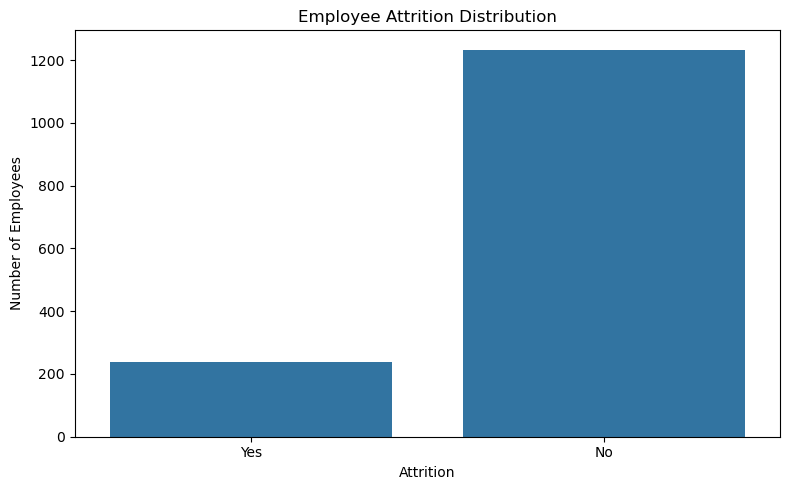

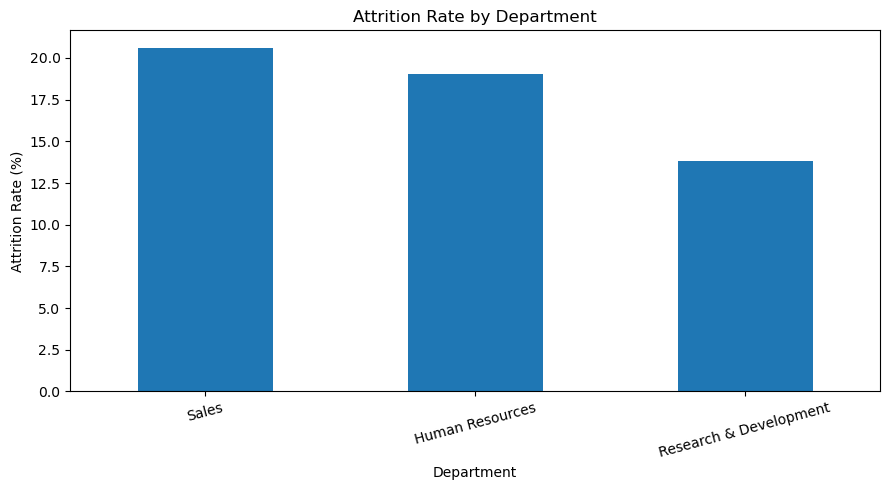

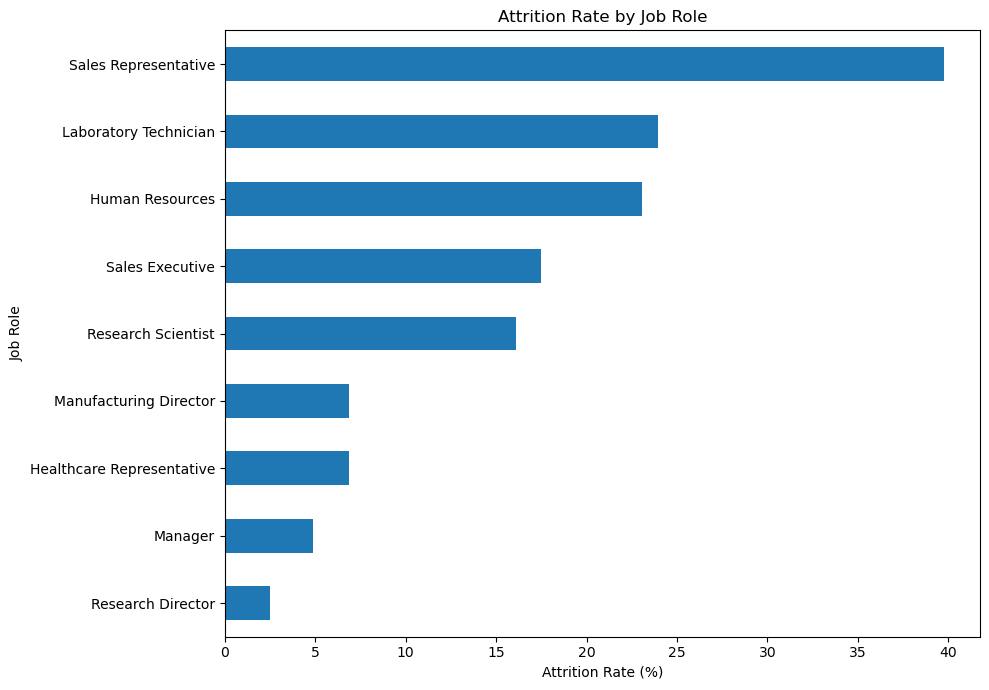

<Figure size 1200x600 with 0 Axes>

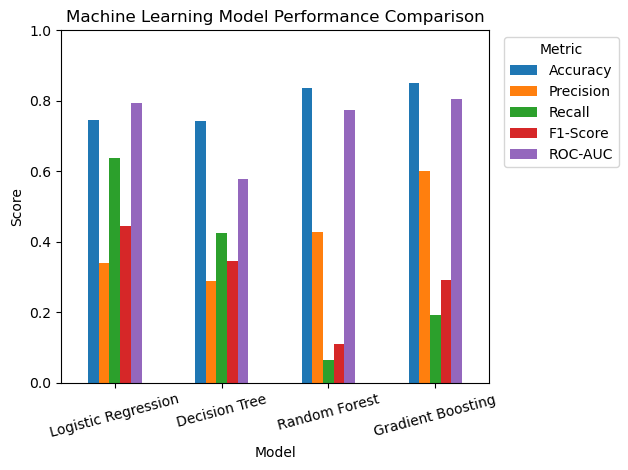

VISUALIZATIONS SAVED SUCCESSFULLY
✓ 01_attrition_distribution.png
✓ 02_department_attrition.png
✓ 03_job_role_attrition.png
✓ 04_model_performance.png


In [23]:
# ============================================
# STEP 23: FINAL PROJECT VISUALIZATIONS
# ============================================

import os

# Create visualization folder if it doesn't exist
os.makedirs("../visualizations", exist_ok=True)


# ---------- 1. ATTRITION DISTRIBUTION ----------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig(
    "../visualizations/01_attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 2. DEPARTMENT ATTRITION ----------

department_rate = (
    df_clean.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

department_rate.plot(
    kind="bar"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../visualizations/02_department_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 3. JOB ROLE ATTRITION ----------

job_role_rate = (
    df_clean.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

job_role_rate.plot(
    kind="barh"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()

plt.savefig(
    "../visualizations/03_job_role_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 4. MODEL PERFORMANCE ----------

performance_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

plt.figure(figsize=(12, 6))

performance_plot.plot(
    kind="bar"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.ylim(0, 1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/04_model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- CONFIRM FILES ----------

print("=" * 60)
print("VISUALIZATIONS SAVED SUCCESSFULLY")
print("=" * 60)

visualization_files = os.listdir("../visualizations")

for file in sorted(visualization_files):
    print("✓", file)

In [24]:
# ============================================
# STEP 24: FINAL PROJECT VERIFICATION
# ============================================

print("=" * 70)
print("EMPLOYEE ATTRITION PREDICTION — FINAL VERIFICATION")
print("=" * 70)

# Dataset
print("\nDATASET")
print("-" * 70)
print(f"Employees: {df_clean.shape[0]}")
print(f"Features after cleaning: {df_clean.shape[1]}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

# Attrition
print("\nATTRITION")
print("-" * 70)
attrition_rate = (
    df_clean["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
)

print(f"Employees who stayed: {attrition_rate['No']:.2f}%")
print(f"Employees who left: {attrition_rate['Yes']:.2f}%")

# Models
print("\nMODEL COMPARISON")
print("-" * 70)

display(
    results_df
    .sort_values("F1-Score", ascending=False)
    .round(4)
)

# Best model
print("\nBEST MODEL")
print("-" * 70)
print(f"Model: {best_model_name}")

best_model_metrics = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"Accuracy : {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall   : {best_model_metrics['Recall']:.4f}")
print(f"F1-Score : {best_model_metrics['F1-Score']:.4f}")
print(f"ROC-AUC  : {best_model_metrics['ROC-AUC']:.4f}")

# Feature importance
print("\nTOP 10 FEATURES")
print("-" * 70)

if "feature_importance_df" in globals():
    display(
        feature_importance_df
        .head(10)
        .round(4)
    )

print("\n" + "=" * 70)
print("PROJECT VERIFICATION COMPLETE")
print("=" * 70)

EMPLOYEE ATTRITION PREDICTION — FINAL VERIFICATION

DATASET
----------------------------------------------------------------------
Employees: 1470
Features after cleaning: 31
Missing values: 0
Duplicate rows: 0

ATTRITION
----------------------------------------------------------------------
Employees who stayed: 83.88%
Employees who left: 16.12%

MODEL COMPARISON
----------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7449,0.3409,0.6383,0.4444,0.7940
1,Decision Tree,0.7415,0.2899,0.4255,0.3448,0.5768
3,Gradient Boosting,0.8503,0.6000,0.1915,0.2903,0.8040
2,Random Forest,0.8367,0.4286,0.0638,0.1111,0.7745



BEST MODEL
----------------------------------------------------------------------
Model: Logistic Regression
Accuracy : 0.7449
Precision: 0.3409
Recall   : 0.6383
F1-Score : 0.4444
ROC-AUC  : 0.7940

TOP 10 FEATURES
----------------------------------------------------------------------


,Feature,Importance
0,categorical__OverTime_Yes,0.8590
1,remainder__StockOptionLevel,0.5057
2,categorical__MaritalStatus_Single,0.4622
3,categorical__IncomeGroup_Low,0.3930
4,remainder__EnvironmentSatisfaction,0.3815
5,categorical__BusinessTravel_Travel_Frequently,0.3779
6,categorical__Department_Sales,0.3695
7,categorical__AgeGroup_36-45,0.3535
8,remainder__PerformanceRating,0.3443
9,categorical__JobRole_Laboratory Technician,0.3435



PROJECT VERIFICATION COMPLETE
